In [ ]:
import torch
import torch.nn as nn
from spin_lattices import KagomeLattice, SquareLattice1Diag, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2
from loguru import logger
from slater_determinant import SlaterDeterminant, tight_binding_init
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def sign_overlap(ground_state, predict_signs):
    probs = ground_state**2
    return torch.dot(ground_state, predict_signs * torch.abs(ground_state)) / probs.sum()

In [ ]:
1

In [11]:
%matplotlib inline

In [12]:
lattice = KagomeLattice(2, 4)
system = HeisenbergJ1J2(lattice, J1=1, J2=1, ground_state_cache_dir=Path("groundstates"))
system.get_eigenstates(1)

ground_state_np = np.real_if_close(system.get_ground_state_in_canonical_basis())
ground_state = torch.from_numpy(ground_state_np)

2023-04-24 17:58:11.879 | DEBUG    | heisenberg_hamiltonians:__init__:427 - use_symmetries is None and lattice is in symmetries whitelist, setting use_symmetries=True, spin_inversion=1
2023-04-24 17:58:11.881 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=24
2023-04-24 17:58:11.887 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-24 17:58:11.950 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 85662
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-04-24 17:58:12.039 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
2023-04-24 17:58:12.042 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -42.8245991763
2023-04-24 17:58:12.043 | DEBUG    | heisenberg

In [19]:
t2s = np.linspace(-2, 2, 11)
overlaps = []
for t2 in t2s:
    initialization = tight_binding_init(ts=[1, t2], keep_symmetries="x")
    det = SlaterDeterminant(
                system.lattice,
                system.canonical_basis,
                initialization=initialization,
                sign_cache_dir=Path("signs_cache"),
            )
    overlap = sign_overlap(ground_state, torch.sign(det(torch.arange(len(system.canonical_basis.states)))))
    overlaps.append(overlap.detach().numpy().item() )


/vol/tcm10/ischurov/frustrations-eda/slater_determinant.py:114: ComplexWarning: Casting complex values to real discards the imaginary part
  return f_ij.astype(np.float64)
2023-04-24 18:00:32.763 | DEBUG    | slater_determinant:__init__:160 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 18:00:39.630 | DEBUG    | slater_determinant:__init__:160 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 18:00:46.094 | DEBUG    | slater_determinant:__init__:160 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 18:00:53.996 | DEBUG    | slater_determinant:__init__:160 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 18:01:27.777 | DEBUG    | slater_determinant:__init__:160 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 18:03:08.256 | DEBUG    | slater_determinant:__init__:160 - Using cached

In [17]:
overlaps = [overlap.detach().numpy().item() for overlap in overlaps]

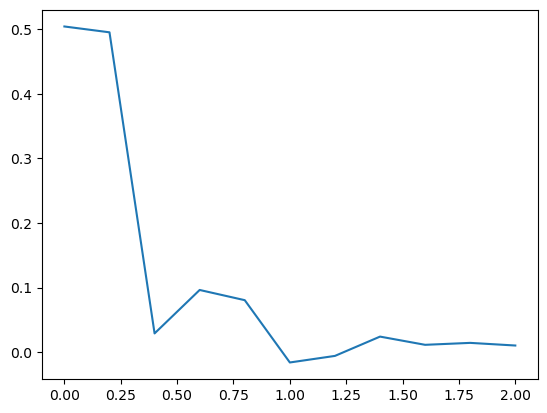

In [18]:
plt.plot(t2s, overlaps)

In [10]:
# with torch.no_grad():
#     det.f.copy_(
#         nn.Parameter(
#             torch.randn(system.number_spins, system.number_spins, dtype=torch.float64)
#             / np.sqrt(system.number_spins)
#         )
#     )

eps_train = 0.001
test_size = 10000
epochs = 100
batch_size = 64
lr = 5e-3
scaling = 1000000

for initialization_strategy in ["orthogonal", ("tight_binding", None), ("tight_binding", "x"), ("tight_binding", "xy")]:
    if initialization_strategy == "orthogonal":
        initialization = "orthogonal"
        keep_symmetries = None
    else:
        keep_symmetries = initialization_strategy[1]
        initialization = tight_binding_init(type_to_t={1: 1.0, 2: 1.0}, keep_symmetries=keep_symmetries)

    for run in range(10):
        dataset_seed = run

        np.random.seed(dataset_seed)
        train_set_numpy = np.random.choice(
            len(system.canonical_basis.states),
            int(eps_train * len(system.canonical_basis.states)),
            replace=False,
            p=ground_state**2,
        )

        train_set = torch.from_numpy(train_set_numpy)
        logger.debug(f"{len(train_set)=}")

        target = (ground_state[train_set] > 0).double()

        rest_set_np = np.setdiff1d(np.arange(len(system.canonical_basis.states)), train_set_numpy)
        rest_probs = ground_state_np[rest_set_np] ** 2
        rest_probs /= rest_probs.sum()
        test_set = torch.from_numpy(np.random.choice(rest_set_np, test_size, replace=False))


        logger.debug(f"{run=}")
        writer = SummaryWriter(
            log_dir=(
                f"experiments/2022_04_24/{datetime.now().strftime('%Y_%m_%d_%H_%M_%S')}"
                f"_{eps_train=}_{batch_size=}_{lr=}_{initialization=}"
                f"_{scaling=}_{keep_symmetries=}"
            )
        )

        torch.manual_seed(run)
        det = SlaterDeterminant(
            system.lattice,
            system.canonical_basis,
            initialization=initialization,
            sign_cache_dir=Path("signs_cache"),
        )

        n_batches = len(train_set) // batch_size

        criterion = nn.BCELoss()

        optimizer = torch.optim.Adam(det.parameters(), lr=lr)

        epoch = 0
        logger.debug(f"{n_batches=}")
        for epoch in range(epochs):  # loop over the dataset multiple times
            i = None
            loss = None

            overlap_train = sign_overlap(ground_state[train_set], torch.sign(det(train_set) * scaling))
            overlap_test = sign_overlap(ground_state[test_set], torch.sign(det(test_set) * scaling))

            # writer.add_scalar("Loss/train", loss.item(), epoch)
            writer.add_scalar("Overlap/train", overlap_train.item(), epoch)
            writer.add_scalar("Overlap/test", overlap_test.item(), epoch)
            # writer.add_scalar("Det_output/std/train", det_output.std().item(), epoch)

            for i in range(n_batches):
                x = train_set[i * batch_size : (i + 1) * batch_size]
                y = target[i * batch_size : (i + 1) * batch_size]

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward + backward + optimize
                det_output = det(x) * scaling
                outputs = torch.sigmoid(det_output)
            
                # print(f"{det_output=}")
                # print(f"{outputs=}")
                # 1/0
                

                #        print(det(x))
                loss = criterion(outputs, y)
                loss.backward()
                #        print(det.f.grad.norm().item())

                optimizer.step()

            assert loss is not None
            
            # log.append(
            #     {
            #         "epoch": epoch,
            #         "loss": loss.item(),
            #         "overlap_train": overlap_train.item(),
            #         "overlap_test": overlap_test.item(),
            #     }
            # )
            # logger.debug(
            #     f"Epoch {epoch} loss: {loss.item():.4f} overlap_train: {overlap_train.item():.4f} "
            #     f"overlap_test: {overlap_test.item():.4f}"
            # )
            

2023-04-24 17:00:30.137 | DEBUG    | __main__:<module>:36 - len(train_set)=2704
2023-04-24 17:00:30.414 | DEBUG    | __main__:<module>:46 - run=0
2023-04-24 17:00:32.667 | DEBUG    | slater_determinant:__init__:153 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 17:00:32.703 | DEBUG    | __main__:<module>:70 - n_batches=42
2023-04-24 17:00:41.127 | DEBUG    | __main__:<module>:36 - len(train_set)=2704
2023-04-24 17:00:41.333 | DEBUG    | __main__:<module>:46 - run=1
2023-04-24 17:00:43.614 | DEBUG    | slater_determinant:__init__:153 - Using cached signs from file signs_cache/d49b2fd515a226965b09a9b91271c65e.npy
2023-04-24 17:00:43.647 | DEBUG    | __main__:<module>:70 - n_batches=42
2023-04-24 17:00:51.829 | DEBUG    | __main__:<module>:36 - len(train_set)=2704
2023-04-24 17:00:52.037 | DEBUG    | __main__:<module>:46 - run=2
2023-04-24 17:00:54.367 | DEBUG    | slater_determinant:__init__:153 - Using cached signs from file signs_cache/d49b2f

In [8]:
self = det
A = torch.randn(self.n_sites, self.n_sites, dtype=torch.float64)
Q, R = torch.linalg.qr(A)
half_Q = Q[:, : self.n_sites // 2]

In [17]:
(half_Q @ half_Q.T).mean()

tensor(0.0120, dtype=torch.float64)

In [20]:
from typing import Literal
from slater_determinant import Initializer
from spin_lattices import SpinLattice
import numpy.typing as npt

In [44]:
def tight_binding_init(
    type_to_t: dict[int, complex],
    keep_symmetries: Literal["x", "xy"] | None = "xy",
) -> Initializer:
    def tight_binding(lattice: SpinLattice) -> npt.NDArray[np.float64]:
        tight_binding_hamiltonian = np.zeros(
            (lattice.number_spins, lattice.number_spins), dtype=np.complex128
        )
        for edge, kind in lattice.edges_to_kind.items():
            tight_binding_hamiltonian[edge[0], edge[1]] = type_to_t[kind]
        tight_binding_hamiltonian = tight_binding_hamiltonian + tight_binding_hamiltonian.T.conj()

        energies, orbitals = np.linalg.eigh(tight_binding_hamiltonian)

        if keep_symmetries is not None and "x" in keep_symmetries:
            tr_x = lattice.x_translation

            ### BASED ON: Nikita Astrakhantsev's code
            e_round = np.around(energies, decimals=7)
            orbitals_tx = orbitals * 0.0 + 0.0j

            tx_momenta = np.zeros(
                orbitals.shape[0], dtype=np.complex128
            )  # this is later needed to select joint (e, t_x) sectors
            for e_sector in np.unique(e_round):
                idxs = np.where(e_round == e_sector)[0]

                print(orbitals[:, idxs].conj().T.shape)
                print(orbitals[:, idxs][tr_x].shape)

                tx_matrix = orbitals[:, idxs].conj().T @ orbitals[tr_x, idxs]

                momenta, Um = schur(tx_matrix)[:2]
                momenta = np.diag(momenta)
                orbitals_tx[:, idxs] = orbitals[:, idxs] @ Um
                tx_momenta[idxs] = momenta
            orbitals = orbitals_tx
            tx_momenta = np.around(tx_momenta, decimals=5)

            if "y" in keep_symmetries:
                tr_y = lattice.y_translation
                orbitals_ty = orbitals * 0.0 + 0.0j

                for e_sector, kx_sector in product(np.unique(e_round), np.unique(tx_momenta)):
                    idxs = np.where((e_round == e_sector) & (tx_momenta == kx_sector))[0]
                    if len(idxs) == 0:
                        continue
                    ty_matrix = orbitals[:, idxs].conj().T @ orbitals[tr_y, idxs]

                    momenta, Um = schur(ty_matrix)[:2]
                    momenta = np.diag(momenta)
                    orbitals_ty[:, idxs] = orbitals[:, idxs].dot(Um)
                orbitals = orbitals_ty

            ### END BASED
        half_orbitals = orbitals[:, : lattice.number_spins // 2]
        f_ij = half_orbitals @ half_orbitals.T.conj()
        return f_ij.astype(np.float64)

    return tight_binding

In [45]:
import matplotlib.pyplot as plt

In [46]:
plt.hist(tight_binding_init({1: 1, 2: 1}, keep_symmetries="x")(system.lattice).reshape(-1))

(9, 24)
(24, 9)


IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (24,) (9,) 